In [1]:
from pathlib import Path
from glob import glob

import xarray as xr
from numpy import allclose
from pandas import DataFrame, Series
import random

from geopy.location import Location
from geopy.geocoders import Nominatim

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import seaborn as sns

sns.set_style('whitegrid')

# Introduction

Data shared contains **storm surge annual maxima data based on the DCPP simulations**. The folder contains 8 netcdf files, containing the data from 8 different models. 

Data is stored using **xarray**, which allows metadata, labels, and coordinates to be embedded directly in the files. As a result, the dataset should be largely self-explanatory and relatively easy to explore.

At each grid point (~ coastal site), there are **three possible bias corrections**: 
- coordinate *bc_flag indicates which bias correction should be used at each grid point*. 
- coordinate *model_valid* indicates whether the data from the model should be considered reliable at a given grid point.

Below, I have included a few simple examples showing how to interrogate the xarray Dataset and extract the data you may need, for convenience.


**Background information on the DCPP simulations**
  * https://confluence.ecmwf.int/display/CKB/CMIP6%3A+Decadal+climate+predictions




**linked packages**
  * https://docs.xarray.dev/en/stable/index.html

# Settings

In [2]:
# color palette finder https://python-graph-gallery.com/color-palette-finder/
colors = ['#7FF9F7FF', '#0B2483FF','#0F8CDEFF','#4C4CFFFF','#040509FF','#23B4DCFF','#3C7084FF']

In [3]:
fs_title = 9.5

In [4]:
geolocator = Nominatim(user_agent="geo_lookup")

In [5]:
export_dir_figures = Path("../../output/figures/exploration")

In [6]:
save_site_plot = True
save_time_series_plot = True

# Loading data

In [7]:
path = '../../input/Annual_max_DCPP_20260112/'

In [8]:
ls_files = [file for file in glob(path + '*.nc')]
ls_files

['../../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [9]:
file_example = ls_files[-2]

In [10]:
model_name = file_example.split('/')[-1].split('Annual_max_')[-1].split('.')[0]
model_name

'CanESM5'

In [11]:
ds = xr.open_dataset(file_example, engine="netcdf4")

# Data Structure

In [12]:
ds

<xarray.Dataset> Size: 349MB
Dimensions:      (sample: 660, member: 2, bc: 3, sites: 11022)
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 654 655 656 657 658 659
  * member       (member) int64 16B 1 2
  * bc           (bc) int64 24B 1 2 3
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) int64 5kB ...
    lead         (sample) int64 5kB ...
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...
Data variables:
    annualMax    (sample, member, bc, sites) float64 349MB ...
Attributes:
    description:  Modelled storm-surge annual maxima organized by simulated y...
    model:        CanESM5

In [13]:
ds["annualMax"].attrs

{'long_name': 'Storm-surge annual maxima', 'units': 'm'}

In [14]:
ds['sim_year'].to_series().describe()

count     660.00000
mean     1993.50000
std        19.06482
min      1961.00000
25%      1977.00000
50%      1993.50000
75%      2010.00000
max      2026.00000
Name: sim_year, dtype: float64

In [15]:
ds.sample.sim_year == 2020

<xarray.DataArray 'sim_year' (sample: 660)> Size: 660B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])
Coordinates:
  * sample    (sample) int64 5kB 0 1 2 3 4 5 6 7 ... 653 654 655 656 657 658 659
    sim_year  (sample) int64 5kB 1961 1961 1961 1961 ... 2026 2026 2026 2026
    lead      (sample) int64 5kB ...

In [16]:
ds['sites']

<xarray.DataArray 'sites' (sites: 11022)> Size: 88kB
array([    0,     1,     2, ..., 11019, 11020, 11021], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

In [17]:
ds["bc_flag"].astype(int)-1 # per site

<xarray.DataArray 'bc_flag' (sites: 11022)> Size: 88kB
array([1, 1, 1, ..., 2, 2, 2], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

# Prepare Data 

### Bias Correction

In [18]:
ds

<xarray.Dataset> Size: 349MB
Dimensions:      (sample: 660, member: 2, bc: 3, sites: 11022)
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 654 655 656 657 658 659
  * member       (member) int64 16B 1 2
  * bc           (bc) int64 24B 1 2 3
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) int64 5kB 1961 1961 1961 1961 ... 2026 2026 2026 2026
    lead         (sample) int64 5kB ...
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...
Data variables:
    annualMax    (sample, member, bc, sites) float64 349MB ...
Attributes:
    description:  Modelled storm-surge annual maxima organized by simulated y...
    model:        CanESM5

In [19]:
annualMax_pref = xr.apply_ufunc(
    lambda v, i: v[i],
    ds["annualMax"],
    ds["bc_flag"].astype(int) - 1,
    input_core_dims=[["bc"], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[ds["annualMax"].dtype],
)

#### Validation

original dimensions are: sample(time), member(ensemble/scenario?), bc, site(location)

In [20]:
site = 100
sample = 500

In [21]:
ds.annualMax[sample,:,:,site].values

array([[1.07831515, 0.96344943, 0.94338611],
       [0.89611038, 0.78124466, 0.78398053]])

In [22]:
ds.annualMax.bc_flag[site].astype(int)-1

<xarray.DataArray 'bc_flag' ()> Size: 8B
array(1)
Coordinates:
    sites        int64 8B 100
    lon          float64 8B ...
    lat          float64 8B ...
    bc_flag      uint8 1B ...
    model_valid  bool 1B ...

In [23]:
# Assert whether the bias correction works as expected 
# dimensions for ds.annualMax sample(time), member: 2, bc: 3, site-id
# dimensions for annualMax_pref sample(time), member: 2, site-id

expected = ds.annualMax[sample, :, ds.annualMax.bc_flag[site].astype(int)-1, site].values 
actual = annualMax_pref[sample, :, site].values

print(f"expected selection: {expected}... asserting whether actual: {actual} matches...")
assert allclose(actual, expected, equal_nan=True)

expected selection: [0.96344943 0.78124466]... asserting whether actual: [0.96344943 0.78124466] matches...


### Discarding non_valid data

In [24]:
data_valid = annualMax_pref.where(ds.model_valid == True, drop=True)

In [25]:
sites_valid = data_valid.shape[-1]
sites_total = annualMax_pref.shape[-1]
rate_invalid = (1 - sites_valid / sites_total) * 100

print(
    f"From {sites_total} sites, only {sites_valid} are model valid; "
    f"{rate_invalid:.2f}% invalid sites removed."
    )

From 11022 sites, only 5782 are model valid; 47.54% invalid sites removed.


# Example Usages

### Extract all annual maxima for a given simulated year (all ensemble members, all lead years)

In [24]:
year = 1980
am_1980 = annualMax_pref.where(ds.sim_year == year, drop=True)

am_1980

<xarray.DataArray 'annualMax' (sample: 10, member: 2, sites: 11022)> Size: 2MB
array([[[0.46863812, 0.48076552, 0.48438268, ..., 1.42719532,
         1.45895521, 1.45449876],
        [0.89144733, 0.89160225, 0.8928011 , ..., 1.91809544,
         1.71327621, 1.70952292]],

       [[0.69307318, 0.70668446, 0.71309567, ..., 2.08256966,
         2.1100599 , 2.11010733],
        [0.71563969, 0.72174943, 0.72289126, ..., 1.66799944,
         1.69020013, 1.69063121]],

       [[0.75405329, 0.76895133, 0.77729127, ..., 1.39386207,
         1.41923376, 1.42261693],
        [0.76605667, 0.77551998, 0.77962398, ..., 1.53954688,
         1.54140836, 1.56597342]],

       ...,

       [[0.77100938, 0.77406598, 0.77622253, ..., 2.04821597,
         2.06073268, 2.05722393],
        [0.63916169, 0.64343973, 0.6434423 , ..., 1.29458305,
         1.31871551, 1.3187291 ]],

       [[0.77533866, 0.7764809 , 0.77753003, ..., 1.55886982,
         1.65963772, 1.67969685],
        [0.94358636, 0.9650949 , 0.96754661, ..., 2.15327823,
         2.18579239, 2.18785386]],

       [[0.51700817, 0.52050964, 0.52080067, ..., 1.59494444,
         1.62341289, 1.62771243],
        [0.76625704, 0.76869107, 0.76862317, ..., 1.55711082,
         1.5738822 , 1.57213241]]], shape=(10, 2, 11022))
Coordinates:
  * sample       (sample) int64 80B 140 141 142 143 144 145 146 147 148 149
  * member       (member) int64 16B 1 2
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 80B 1.98e+03 1.98e+03 ... 1.98e+03 1.98e+03
    lead         (sample) float64 80B 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0
    lon          (sites) float64 88kB 9.397 9.73 9.934 ... 3.791 3.768 3.74
    lat          (sites) float64 88kB 64.37 64.34 64.31 ... 51.64 51.65 51.65
    bc_flag      (sites) uint8 11kB 2 2 2 2 2 2 2 2 2 2 ... 3 3 3 3 3 3 3 3 3 3
    model_valid  (sites) bool 11kB True True True True ... False False False
Attributes:
    long_name:  Storm-surge annual maxima
    units:      m

### Extract year + specific lead year

In [17]:
year = 1980
lead = 3
am_1980_l3 = annualMax_pref.where(
    (ds.sim_year == year) & (ds.lead == lead),
    drop=True
)

am_1980_l3

<xarray.DataArray 'annualMax' (sample: 1, member: 2, sites: 11022)> Size: 176kB
array([[[0.66726597, 0.67582189, 0.67497484, ..., 1.65118601,
         1.6788996 , 1.69099914],
        [0.54760871, 0.54957853, 0.54867505, ..., 1.53948695,
         1.55190766, 1.5482507 ]]], shape=(1, 2, 11022))
Coordinates:
  * sample       (sample) int64 8B 192
  * member       (member) int64 16B 1 2
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 8B 1.98e+03
    lead         (sample) float64 8B 3.0
    lon          (sites) float64 88kB 9.397 9.73 9.934 ... 3.791 3.768 3.74
    lat          (sites) float64 88kB 64.37 64.34 64.31 ... 51.64 51.65 51.65
    bc_flag      (sites) uint8 11kB 3 3 3 3 3 3 3 3 3 3 ... 2 2 2 2 2 2 2 2 2 2
    model_valid  (sites) bool 11kB True True True True ... False False True True
Attributes:
    long_name:  Storm-surge annual maxima
    units:      m

### Extract time series at one site (all years and leads)

In [18]:
site_id = 5000
am_site = annualMax_pref.isel(sites=site_id)
ti = am_site['sim_year'].values
lyr = am_site['lead'].values
ami = am_site.values


# Display Model Locations 
Which locations are we looking at? which one are valid?

In [26]:
df = DataFrame([ds.lon.values, ds.lat.values, ds.model_valid.values], index=['lon', 'lat', 'model_valid']).T
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11022 entries, 0 to 11021
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   lon          11022 non-null  object
 1   lat          11022 non-null  object
 2   model_valid  11022 non-null  object
dtypes: object(3)
memory usage: 258.5+ KB


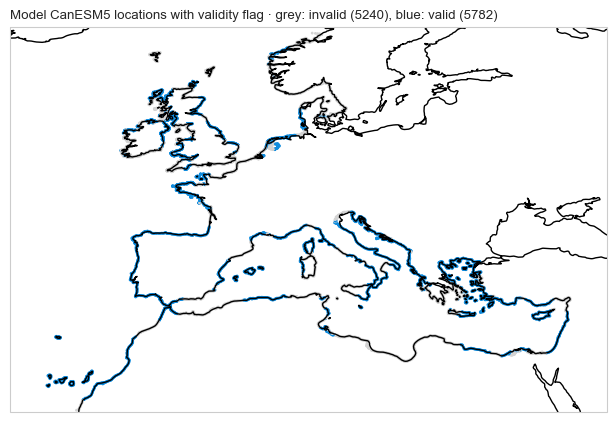

saving map to ../../output/figures/exploration as model_CanESM5_site_validity_map.png


In [27]:
fig, ax = plt.subplots(figsize=(13, 5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_title(
    f"Model {model_name} locations with validity flag · grey: invalid ({sites_total-sites_valid}), "
    f"blue: valid ({sites_valid})", 
    loc='left', fontsize=fs_title
    )

cmap = ListedColormap(["lightgrey", colors[2]])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

ax.scatter(
    df["lon"], df["lat"],
    c=df["model_valid"].astype(int), s=1, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_extent([-22, 40, 25, 65], crs=ccrs.PlateCarree()) 

plt.show()

if save_site_plot:
    export_dir_figures.mkdir(parents=True, exist_ok=True)
    file_name = f"model_{model_name}_site_validity_map.png"
    print(f"saving map to {export_dir_figures} as {file_name}")
    
    fig.savefig(
        export_dir_figures / file_name, dpi=300, bbox_inches='tight'
        )


# Display Timeseries at a specific location

1. Simulation year (init year)
This is the year when the model forecast was initialized.<br>
*Example: sim_year = 1995 means the model started from conditions in 1995.*

2. Lead time
How far into the future the model is predicting from the init year. Often in months or years.<br>
*Example:*
   - lead = 0 → initial state (or first forecast period)
   - lead = 1 → 1 year (or 1 month) after initialization
   - lead = 5 → 5 years after initialization

1. The actual time represented by a data point
The valid (verification) time is:
$valid year = sim year + lead$


**Questions to look at**<br>
A. *“What did the 1990 forecast predict over time?”* → Fix init year → see forecast evolution<br>
B. *“How good are 3-year lead forecasts across all hindcasts?”* → Fix lead time → compare across init years

In [53]:
location = geolocator.geocode("Almere, the Netherlands")
location.latitude, location.longitude

(52.3705038, 5.2185859)

In [ ]:
am_site

In [89]:
def find_closest_site_xr(sites_da, target_lat, target_lon):
    dist2 = (sites_da.lat - target_lat)**2 + (sites_da.lon - target_lon)**2
    
    idx_min = dist2.argmin().item()
    
    return {
        "site_id": sites_da.sites[idx_min].item(),
        "lat": sites_da.lat[idx_min].item(),
        "lon": sites_da.lon[idx_min].item()
    }


site_found = find_closest_site_xr(am_site.sites, location.latitude, location.longitude)
site_found

IndexError: too many indices

In [86]:
site_id = site_found['site_id']

In [87]:
am_site = data_valid.isel(sites=site_id) # data_valid[:, :, site_id] - sample, member, annualMax

sim_years = am_site.sim_year.to_series().unique().astype(int)
lead = am_site.lead.to_series().unique()

In [88]:
try:
    location = geolocator.reverse((am_site.lat.values, am_site.lon.values))
except: 
    location = None
location

Location(Boi Virón, A Camposa, Muxía, Fisterra, A Coruña, Galicia, 15124, España, (43.0998126, -9.2210638, 0.0))

In [385]:
df_site = DataFrame(am_site.values, columns=['annualMax_member0', 'annualMax_member1'])
df_site['sim_year'] = DataFrame(am_site['sim_year'].values.astype(int))
df_site['lead'] = DataFrame(am_site['lead'].values.astype(int))
df_site['valid_year'] = df_site.sim_year + df_site.lead

df_site.dropna()

,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
0,0.223867,0.307895,1961,1,1962
10,0.308450,0.290474,1962,1,1963
11,0.240693,0.288436,1962,2,1964
20,0.353047,0.357348,1963,1,1964
21,0.206870,0.248382,1963,2,1965
...,...,...,...,...,...
638,0.182387,0.197727,2024,9,2033
639,0.237675,0.149911,2024,10,2034
648,0.310618,0.190638,2025,9,2034
649,0.214572,0.294374,2025,10,2035


### A. “What did the *sim_year* forecast predict over time?”
Fix init year → see forecast evolution<br>

In [386]:
sim_years

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])

In [388]:
sim_year_selected = random.choice(sim_years)
sim_year_selected

np.int64(2025)

In [335]:
def select_location_data_with_inityear(df_site: DataFrame, sim_year_selected: int) -> DataFrame:
    return df_site[df_site.sim_year == sim_year_selected].sort_values('valid_year')

# ----------------------------------------------------

sim_year_forecast = select_location_data_with_inityear(df_site, sim_year_selected)
sim_year_forecast

,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
620,NaN,NaN,2028,1,2029
621,NaN,NaN,2028,2,2030
622,NaN,NaN,2028,3,2031
623,NaN,NaN,2028,4,2032
624,NaN,NaN,2028,5,2033
625,NaN,NaN,2028,6,2034
626,NaN,NaN,2028,7,2035
627,NaN,NaN,2028,8,2036
628,NaN,NaN,2028,9,2037
629,0.924247,1.091216,2028,10,2038


saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-2028_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png


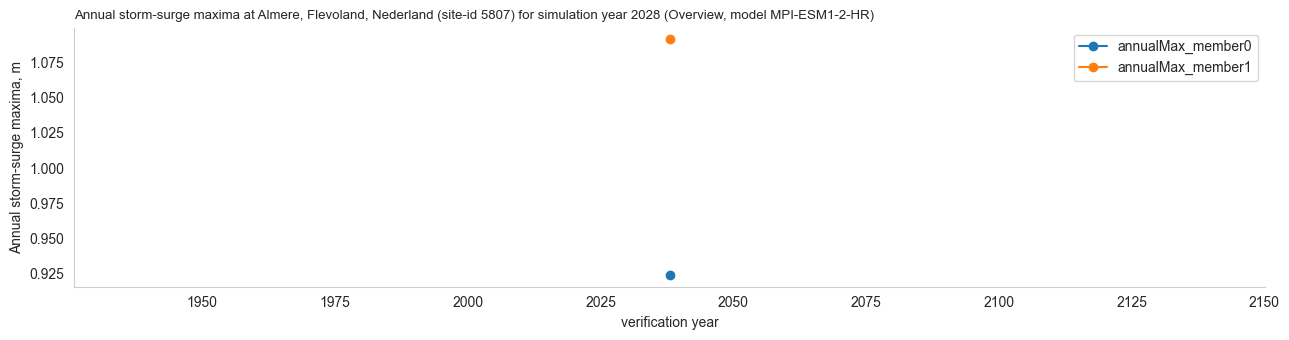

In [336]:
def plot_forecast_timeseries_from_inityear_for_location( 
    sim_year_forecast: DataFrame, sim_year_selected: int, location: Location, site_id:int, model_name: str,
    save_time_series_plot: bool = True,  figsize=(13, 3.5), 
    ) -> plt.Figure:
    
    fig, ax = plt.subplots(figsize=figsize)
    title = "Annual storm-surge maxima at "
    title += f"{location.address} (site-id {site_id})" if location else f"site-id {site_id}"
    ax.set_title(
        title + f" for simulation year {sim_year_selected} (Overview, model {model_name})", 
        loc='left', fontsize=fs_title
        )

    sim_year_forecast.set_index('valid_year').filter(like='annualMax').plot(ax=ax, marker='o')

    ax.set_ylabel('Annual storm-surge maxima, m')
    ax.set_xlabel('verification year')

    ax.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_time_series_plot:
        export_dir_figures.mkdir(parents=True, exist_ok=True)
        file_name = f"sim_year/forecast_with_simyear-{sim_year_selected}_for_{location}_model_{model_name}.png"
        print(f"saving map to {export_dir_figures/"sim_year"} as {file_name}")
        
        fig.savefig(
            export_dir_figures / file_name, dpi=300, bbox_inches='tight'
            )

    plt.close(fig)
    return fig

# ----------------------------------------------------

fig = plot_forecast_timeseries_from_inityear_for_location(
    sim_year_forecast, sim_year_selected, location, site_id, model_name,save_time_series_plot=True
    )
fig
    

#### Full run through all options

In [389]:
years_selected_for_comparison = [1966, 1988, 1999, 2006, 2010, 2021, 2024, 2026, 2028]

In [390]:
for sim_year_selected in years_selected_for_comparison: 
    sim_year_forecast = select_location_data_with_inityear(df_site, int(sim_year_selected))

    fig = plot_forecast_timeseries_from_inityear_for_location(
        sim_year_forecast, sim_year_selected, location, site_id, model_name,save_time_series_plot=True
        )


saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-1966_for_Fábrica, Vila Nova de Cacela, Vila Real de Santo António, Faro, 8900-030, Portugal_model_CanESM5.png
saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-1988_for_Fábrica, Vila Nova de Cacela, Vila Real de Santo António, Faro, 8900-030, Portugal_model_CanESM5.png
saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-1999_for_Fábrica, Vila Nova de Cacela, Vila Real de Santo António, Faro, 8900-030, Portugal_model_CanESM5.png
saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-2006_for_Fábrica, Vila Nova de Cacela, Vila Real de Santo António, Faro, 8900-030, Portugal_model_CanESM5.png
saving map to ../../output/figures/exploration/sim_year as sim_year/forecast_with_simyear-2010_for_Fábrica, Vila Nova de Cacela, Vila Real de Santo António, Faro, 8900-030, Portugal_model_CanESM5.png


### B. “How good are *x-year lead forecasts* across all hindcasts?”
Fix lead time → compare across init years

In [347]:
lead_selected = random.choice(lead).astype(int)
lead_selected = 3

In [348]:
def select_location_data_with_lead(df_site: DataFrame, lead_selected: int) -> DataFrame:
    lead_year_forecast = df_site[df_site.lead == lead_selected]
    return lead_year_forecast.sort_values('valid_year')

# ----------------------------------------------------

lead_year_forecast = select_location_data_with_lead(df_site, lead_selected)
lead_year_forecast

,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
2,NaN,NaN,1966,3,1969
12,NaN,NaN,1967,3,1970
22,1.201439,0.830952,1968,3,1971
32,NaN,1.184296,1969,3,1972
42,0.923865,0.921945,1970,3,1973
...,...,...,...,...,...
582,NaN,NaN,2024,3,2027
592,NaN,NaN,2025,3,2028
602,NaN,NaN,2026,3,2029
612,NaN,NaN,2027,3,2030


saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-3_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png


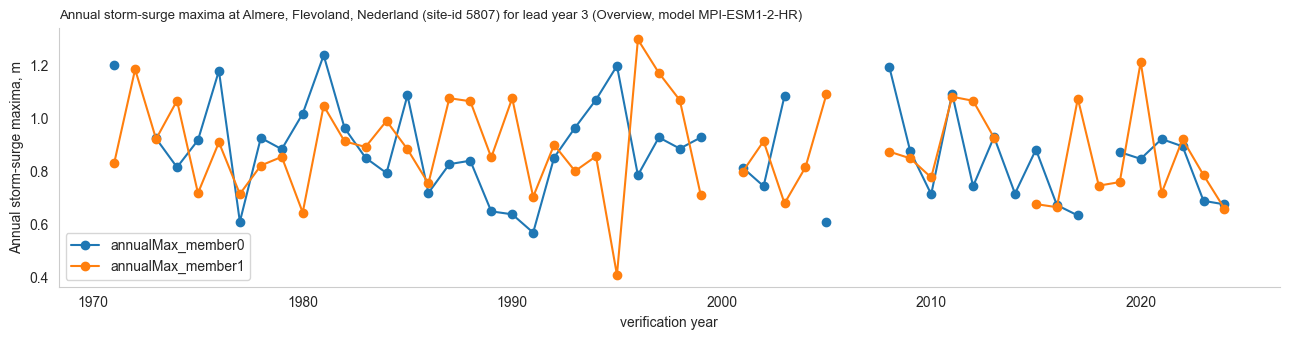

In [349]:
def plot_forecast_quality_at_location_for_leadyear(
    lead_year_forecast: DataFrame, lead_selected: int, location: Location, site_id:int, model_name: str, 
    save_time_series_plot: bool = True, figsize=(13, 3.5), 
    ) -> plt.Figure:
    
    fig, ax = plt.subplots(figsize=figsize)
    
    title = "Annual storm-surge maxima at "
    title += f"{location.address} (site-id {site_id})" if location else f"site-id {site_id}"
    ax.set_title(
        title + f" for lead year {lead_selected} (Overview, model {model_name})", 
        loc='left', fontsize=fs_title
        )

    lead_year_forecast.set_index('valid_year').filter(like='annualMax').plot(ax=ax, marker='o')

    ax.set_ylabel('Annual storm-surge maxima, m')
    ax.set_xlabel('verification year')

    ax.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_time_series_plot:
        export_dir_figures.mkdir(parents=True, exist_ok=True)
        file_name = f"lead/forecastQuality_at_leadyear-{lead_selected}_for_{location}_model_{model_name}.png"
        print(f"saving map to {export_dir_figures} as: {file_name}")
        
        fig.savefig(
            export_dir_figures / file_name, dpi=300, bbox_inches='tight'
            )
    plt.close(fig)
    return fig

# ----------------------------------------------------

fig = plot_forecast_quality_at_location_for_leadyear(
    lead_year_forecast, lead_selected, location, site_id, model_name, save_time_series_plot=True
    )

fig

#### Full run through all options

In [353]:
for lead_selected in lead: 
    lead_year_forecast = select_location_data_with_lead(df_site, int(lead_selected))

    fig = plot_forecast_quality_at_location_for_leadyear(
        lead_year_forecast, int(lead_selected), location, site_id, model_name, save_time_series_plot=True
        )


saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-1_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-2_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-3_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-4_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-5_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-6_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png
saving map to ../../output/figures/exploration as: lead/forecastQuality_at_leadyear-7_for_Almere, Flevoland, Nederland_model_MPI-ESM1-2-HR.png